In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/ZP

/content/drive/MyDrive/Colab Notebooks/ZP


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
autoscout_data=pd.read_csv('listings.csv')
autoscout_data.head(20)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
5,Audi A1,Sedans,15090,VAT deductible,63668.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,85.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1135.0,front,3.5
6,Audi A1,Station wagon,16422,VAT deductible,62111.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,On-bo...",...,1.0,85.0,1,Metallic,Part/Full Leather,Automatic,1598.0,1195.0,front,3.7
7,Audi A1,Compact,14480,VAT deductible,14986.0,Used,Diesel,7.0,"Air conditioning,Armrest,Electrical side mirro...","CD player,MP3,Radio",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1180.0,front,3.7
8,Audi A1,Sedans,16700,VAT deductible,57000.0,Used,Diesel,7.0,"Air conditioning,Power windows",Radio,...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1275.0,front,3.7
9,Audi A1,Sedans,17990,VAT deductible,16103.0,Used,Benzine,7.0,"Air conditioning,Armrest,Automatic climate con...",Radio,...,1.0,70.0,0,Metallic,Cloth,Automatic,999.0,1135.0,front,4.2


In [5]:
print(autoscout_data.shape)

(15915, 23)


## Ciscenje podataka

In [6]:
print(autoscout_data.isna().any(axis=0).sum())
print(autoscout_data.isna().any(axis=1).sum())

0
0


Nema nedostajajucih vrijednosti.

In [7]:
print(autoscout_data.duplicated().sum())

1673


U datasetu postoji 1673 duplikata, uklonit cemo ih.

In [8]:
autoscout_data.drop_duplicates(inplace=True)
print(autoscout_data.duplicated().sum())

0


In [9]:
print(autoscout_data.dtypes)

make_model              object
body_type               object
price                    int64
vat                     object
km                     float64
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Extras                  object
Safety_Security         object
age                    float64
Previous_Owners        float64
hp_kW                  float64
Inspection_new           int64
Paint_Type              object
Upholstery_type         object
Gearing_Type            object
Displacement_cc        float64
Weight_kg              float64
Drive_chain             object
cons_comb              float64
dtype: object


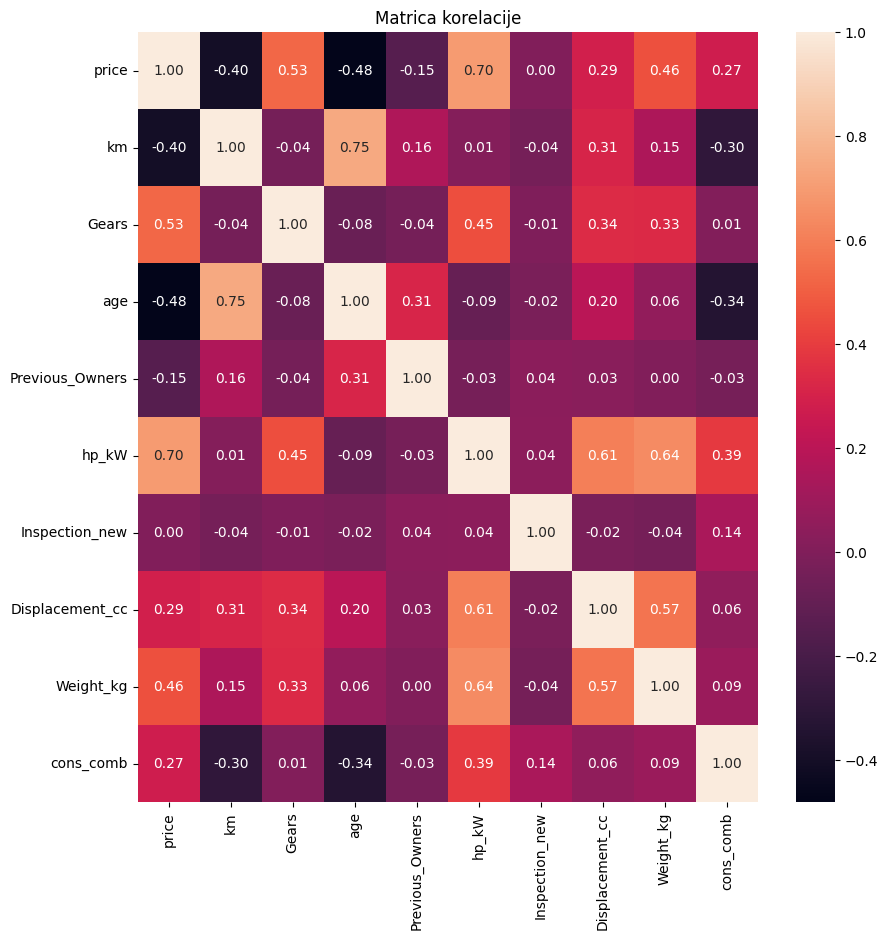

In [10]:
numeric_df=autoscout_data.select_dtypes(include=np.number)
plt.figure(figsize=(10,10))
sns.heatmap(numeric_df.corr(),annot=True,fmt='.2f')
plt.title('Matrica korelacije')
plt.show()

In [11]:
for column in autoscout_data.select_dtypes(include='object').columns:
    print(f"Column: {column}")
    print(autoscout_data[column].value_counts())
    print("\n" + "-"*50 + "\n")

Column: make_model
make_model
Audi A3           2758
Opel Insignia     2417
Audi A1           2377
Opel Astra        2305
Opel Corsa        1994
Renault Clio      1486
Renault Espace     884
Renault Duster      20
Audi A2              1
Name: count, dtype: int64

--------------------------------------------------

Column: body_type
body_type
Sedans           7230
Station wagon    3405
Compact          2710
Van               735
Transporter        87
Off-Road           42
Coupe              25
Convertible         8
Name: count, dtype: int64

--------------------------------------------------

Column: vat
vat
VAT deductible      13426
Price negotiable      816
Name: count, dtype: int64

--------------------------------------------------

Column: Type
Type
Used              10172
New                1369
Pre-registered     1029
Employee's car      905
Demonstration       767
Name: count, dtype: int64

--------------------------------------------------

Column: Fuel
Fuel
Benzine     7558
Di

In [12]:
for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    # Zamijena NaN vrijednostri sa praznim stringom
    autoscout_data[col] = autoscout_data[col].fillna('')
    # Podjela stringa po zarezima i uklanjanje whitespacea
    autoscout_data[col] = autoscout_data[col].apply(lambda x: [item.strip() for item in x.split(',') if item.strip()])

print(autoscout_data[['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']].head())

                                 Comfort_Convenience  \
0  [Air conditioning, Armrest, Automatic climate ...   
1  [Air conditioning, Automatic climate control, ...   
2  [Air conditioning, Cruise control, Electrical ...   
3  [Air suspension, Armrest, Auxiliary heating, E...   
4  [Air conditioning, Armrest, Automatic climate ...   

                                 Entertainment_Media  \
0  [Bluetooth, Hands-free equipment, On-board com...   
1  [Bluetooth, Hands-free equipment, On-board com...   
2                           [MP3, On-board computer]   
3  [Bluetooth, CD player, Hands-free equipment, M...   
4  [Bluetooth, CD player, Hands-free equipment, M...   

                                              Extras  \
0  [Alloy wheels, Catalytic Converter, Voice Cont...   
1  [Alloy wheels, Sport seats, Sport suspension, ...   
2                      [Alloy wheels, Voice Control]   
3         [Alloy wheels, Sport seats, Voice Control]   
4  [Alloy wheels, Sport package, Sport suspens

In [13]:
all_unique_features = set()

for col in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']:
    for feature_list in autoscout_data[col]:
        if isinstance(feature_list, list):
            for feature in feature_list:
                all_unique_features.add(feature)

unique_features_list = list(all_unique_features)
print(f"Ekstraktirano jedinstvenih featurea: {len(unique_features_list)}")
print("Prvih 20:")
print(unique_features_list[:20])

Ekstraktirano jedinstvenih featurea: 94
Prvih 20:
['Parking assist system self-steering', 'Light sensor', 'Television', 'Roof rack', 'Traction control', 'Winter tyres', 'Xenon headlights', 'Split rear seats', 'Handicapped enabled', 'Electrically heated windshield', 'Cab or rented Car', 'Seat ventilation', 'Hill Holder', 'Electric Starter', 'Keyless central door lock', 'Armrest', 'Electrically adjustable seats', 'Electronic stability control', 'Parking assist system sensors rear', 'Sunroof']


## Enkodiranje

In [14]:
import pandas as pd

one_hot_encoded_df = pd.DataFrame(index=autoscout_data.index)

feature_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

# Iteriranje kroz unique znacajke
for feature in unique_features_list:
    column_name_for_feature = f'feature_{feature}'
    one_hot_encoded_df[column_name_for_feature] = 0

    # Provjera prisutnost trenutne značajke u svakoj od četiri originalne kolone
    for original_list_col in feature_cols:
        one_hot_encoded_df[column_name_for_feature] = \
            one_hot_encoded_df[column_name_for_feature] | \
            autoscout_data[original_list_col].apply(lambda x: 1 if feature in x else 0)

autoscout_data = autoscout_data.drop(columns=feature_cols)
autoscout_data = pd.concat([autoscout_data, one_hot_encoded_df], axis=1)
print(autoscout_data.head())
print(f"Shape: {autoscout_data.shape}")

  make_model body_type  price               vat       km  Type     Fuel  \
0    Audi A1    Sedans  15770    VAT deductible  56013.0  Used   Diesel   
1    Audi A1    Sedans  14500  Price negotiable  80000.0  Used  Benzine   
2    Audi A1    Sedans  14640    VAT deductible  83450.0  Used   Diesel   
3    Audi A1    Sedans  14500    VAT deductible  73000.0  Used   Diesel   
4    Audi A1    Sedans  16790    VAT deductible  16200.0  Used   Diesel   

   Gears  age  Previous_Owners  ...  feature_Wind deflector  \
0    7.0  3.0              2.0  ...                       0   
1    7.0  2.0              1.0  ...                       0   
2    7.0  3.0              1.0  ...                       0   
3    6.0  3.0              1.0  ...                       0   
4    7.0  3.0              1.0  ...                       0   

   feature_Lumbar support feature_Leather steering wheel feature_Touch screen  \
0                       0                              1                    0   
1       

In [15]:
categorical_cols = autoscout_data.select_dtypes(include='object').columns
print(f"Presotali kategoricki stupci za enkodiranje: {list(categorical_cols)}")

Presotali kategoricki stupci za enkodiranje: ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']


In [16]:
autoscout_data_encoded = pd.get_dummies(autoscout_data, columns=categorical_cols, drop_first=False)
print(autoscout_data_encoded.head())

   price       km  Gears  age  Previous_Owners  hp_kW  Inspection_new  \
0  15770  56013.0    7.0  3.0              2.0   66.0               1   
1  14500  80000.0    7.0  2.0              1.0  141.0               0   
2  14640  83450.0    7.0  3.0              1.0   85.0               0   
3  14500  73000.0    6.0  3.0              1.0   66.0               0   
4  16790  16200.0    7.0  3.0              1.0   66.0               1   

   Displacement_cc  Weight_kg  cons_comb  ...  Paint_Type_Perl effect  \
0           1422.0     1220.0        3.8  ...                   False   
1           1798.0     1255.0        5.6  ...                   False   
2           1598.0     1135.0        3.8  ...                   False   
3           1422.0     1195.0        3.8  ...                   False   
4           1422.0     1135.0        4.1  ...                   False   

   Paint_Type_Uni/basic  Upholstery_type_Cloth  \
0                 False                   True   
1                 Fals

## Distribucija

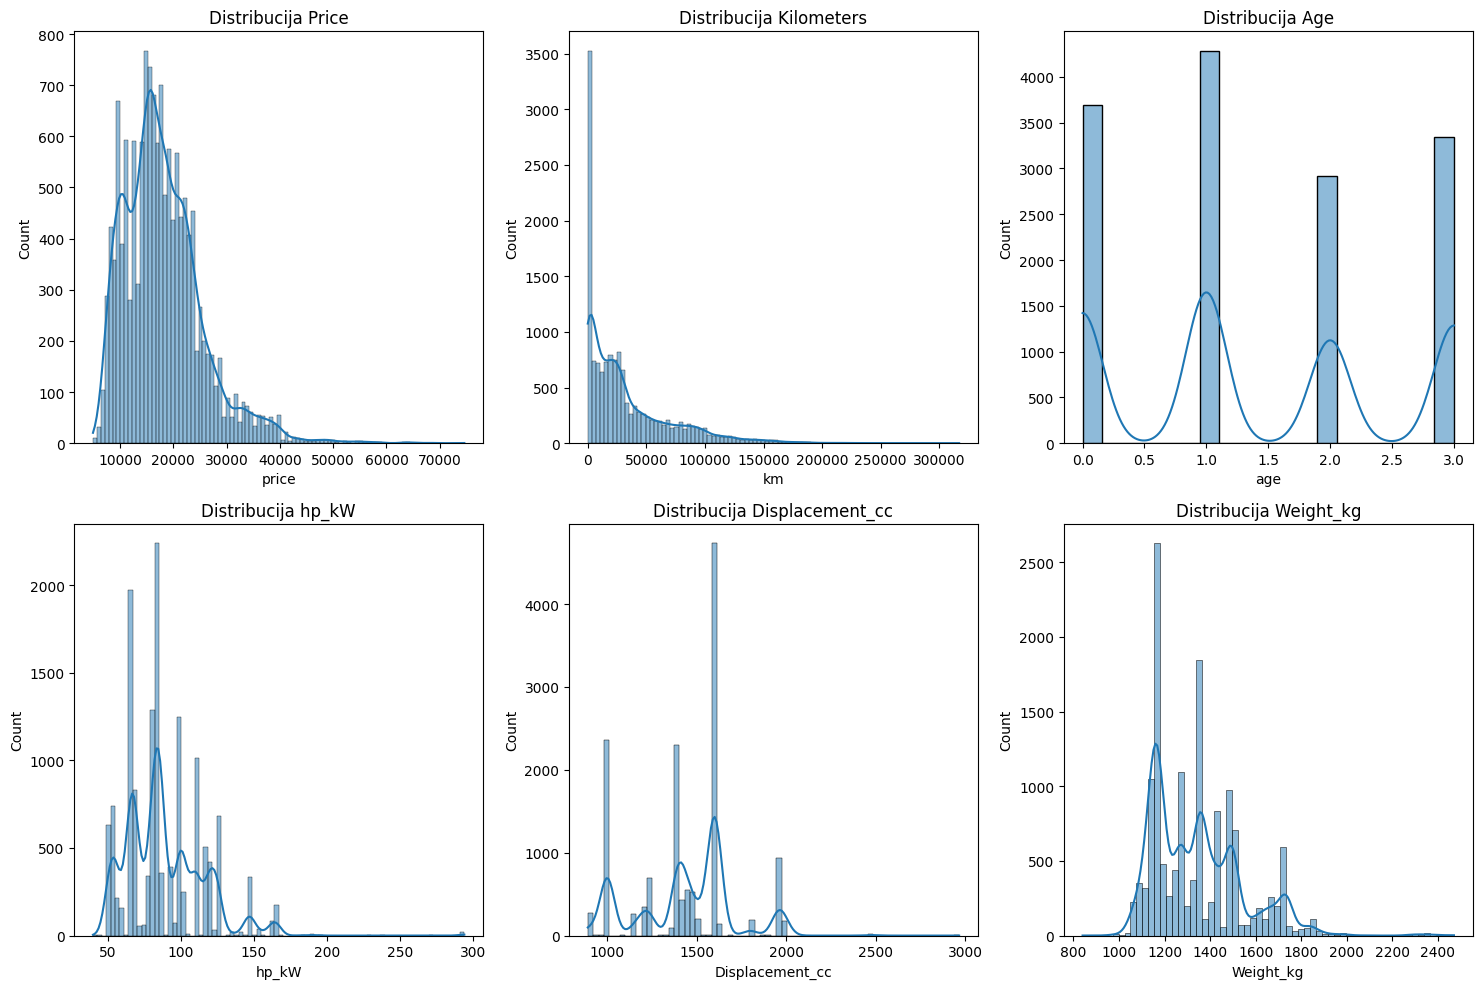

In [17]:
# Vizualizacija distribucija kljucnih numerickih znacajki
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(autoscout_data_encoded['price'], kde=True)
plt.title('Distribucija Price')

plt.subplot(2, 3, 2)
sns.histplot(autoscout_data_encoded['km'], kde=True)
plt.title('Distribucija Kilometers')

plt.subplot(2, 3, 3)
sns.histplot(autoscout_data_encoded['age'], kde=True)
plt.title('Distribucija Age')

plt.subplot(2, 3, 4)
sns.histplot(autoscout_data_encoded['hp_kW'], kde=True)
plt.title('Distribucija hp_kW')

plt.subplot(2, 3, 5)
sns.histplot(autoscout_data_encoded['Displacement_cc'], kde=True)
plt.title('Distribucija Displacement_cc')

plt.subplot(2, 3, 6)
sns.histplot(autoscout_data_encoded['Weight_kg'], kde=True)
plt.title('Distribucija Weight_kg')

plt.tight_layout()
plt.show()

## Detaljna analiza distribucije cijene

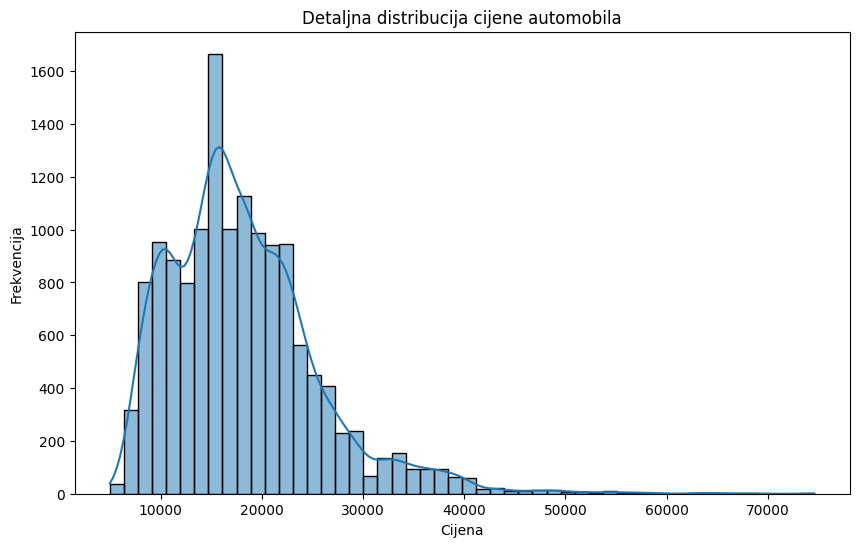

Skewness cijene: 1.27
Cijena je značajno pozitivno iskrivljena, koristi log-transformaciju.


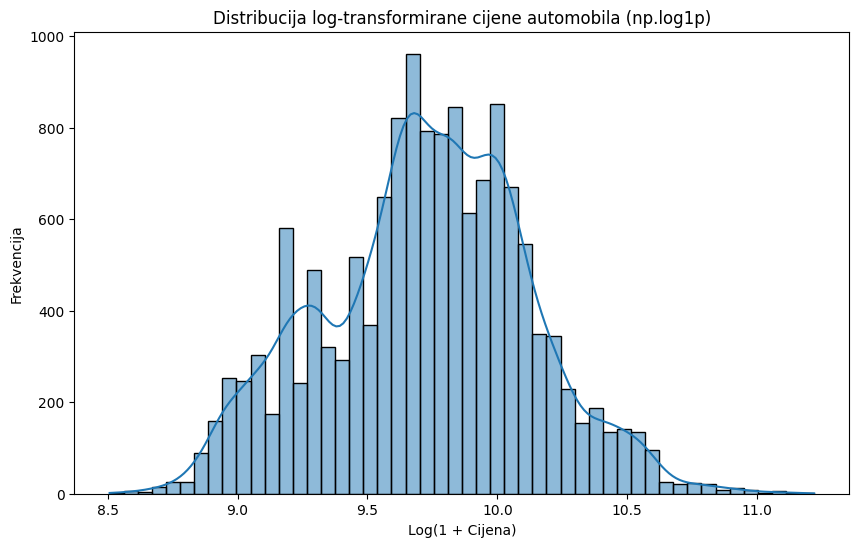

In [18]:
# Provjera distribucije cijene s KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 6))
sns.histplot(autoscout_data_encoded['price'], kde=True, bins=50)
plt.title('Detaljna distribucija cijene automobila')
plt.xlabel('Cijena')
plt.ylabel('Frekvencija')
plt.show()

# Provjera skewnessa
price_skewness = autoscout_data_encoded['price'].skew()
print(f"Skewness cijene: {price_skewness:.2f}")

if price_skewness > 0.5:
    print("Cijena je značajno pozitivno iskrivljena, koristi log-transformaciju.")
    # Vizualizacija log-transformirane cijene
    plt.figure(figsize=(10, 6))
    sns.histplot(np.log1p(autoscout_data_encoded['price']), kde=True, bins=50)
    plt.title('Distribucija log-transformirane cijene automobila (np.log1p)')
    plt.xlabel('Log(1 + Cijena)')
    plt.ylabel('Frekvencija')
    plt.show()

## Odnos cijene s ključnim numeričkim značajkama (dijagram raspršenja)

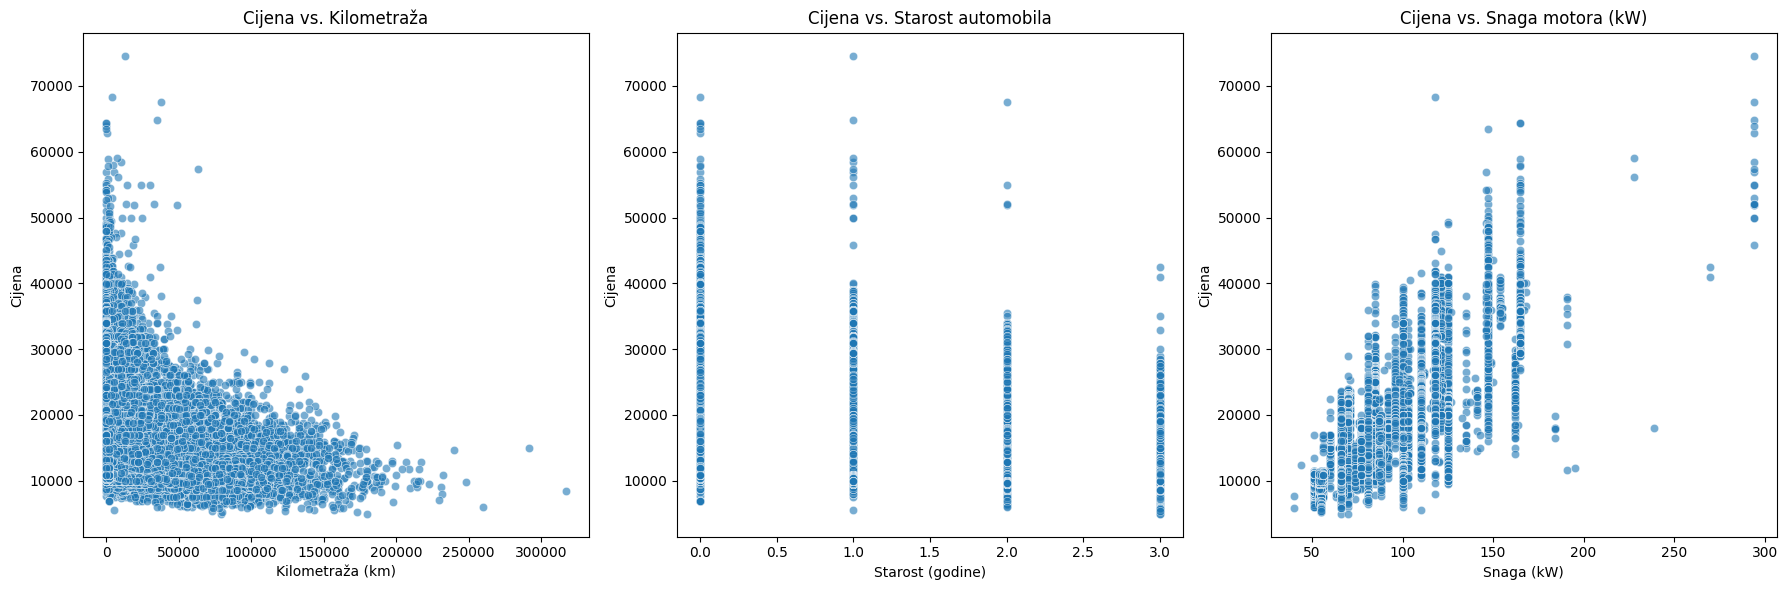

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='km', y='price', data=autoscout_data_encoded, alpha=0.6)
plt.title('Cijena vs. Kilometraža')
plt.xlabel('Kilometraža (km)')
plt.ylabel('Cijena')

plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='price', data=autoscout_data_encoded, alpha=0.6)
plt.title('Cijena vs. Starost automobila')
plt.xlabel('Starost (godine)')
plt.ylabel('Cijena')

plt.subplot(1, 3, 3)
sns.scatterplot(x='hp_kW', y='price', data=autoscout_data_encoded, alpha=0.6)
plt.title('Cijena vs. Snaga motora (kW)')
plt.xlabel('Snaga (kW)')
plt.ylabel('Cijena')

plt.tight_layout()
plt.show()

## Train/Test Split

In [20]:
x=autoscout_data_encoded.drop('price',axis=1)
y=autoscout_data_encoded['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print( f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (11393, 142)
Shape of y_train: (11393,)
Shape of x_test: (2849, 142)
Shape of y_test: (2849,)


## RandomForestRegressor

Koristi se jer dobro hvata nelinearne odnose, robustan je na šum i outliere te radi solidno cak i bez tuninga hiperparametara. Slabost mu je sto zahtjeva veliku kolicinu memorije.

In [21]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)
print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_rf = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 985.77
Mean Squared Error (MSE): 3005784.62
R-squared (R2 Score): 0.95


## GradientBoostingRegressor

Koristi se jer dobro uci kompleksne uzorke(npr. stari BMW s malom kilometražom ≠ stari Citroen s malom kilometražom) te dobro radi sa raznim tipovima znacajki.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(x_train, y_train)
print("GradientBoostingRegressor model trained successfully.")

GradientBoostingRegressor model trained successfully.


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_gbr = gbr_model.predict(x_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"GradientBoostingRegressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"R-squared (R2 Score): {r2_gbr:.2f}")

GradientBoostingRegressor Metrics:
Mean Absolute Error (MAE): 1334.29
Mean Squared Error (MSE): 4083175.61
R-squared (R2 Score): 0.93


## Usporedba performansi modela
### Metrike RandomForestRegressor modela:

Srednja apsolutna pogreška (MAE): 985.77
Srednja kvadratna pogreška (MSE): 3005784.62
R-squared (R2 Score): 0.95

### Metrike GradientBoostingRegressor modela:

Srednja apsolutna pogreška (MAE): 1334.29
Srednja kvadratna pogreška (MSE): 4083175.61
R-squared (R2 Score): 0.93
### Zaključak:

RandomForestRegressor ima nižu srednju apsolutnu pogrešku (MAE: 985.77 vs 1334.29) i nižu srednju kvadratnu pogrešku (MSE: 3005784.62 vs 4083175.61).
RandomForestRegressor također ima viši R-squared rezultat (0.95 vs 0.93).
Na temelju ovih rezultata, model RandomForestRegressor pokazuje bolje performanse za predviđanje cijena automobila jer ima niže stope pogrešaka i objašnjava više varijance u ciljnoj varijabli.

## Tuning Hiperparametara


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [26]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=60, cv=5, verbose=2, random_state=42, n_jobs=-1)

random_search.fit(x_train, y_train)

print("Best parameters found: ", random_search.best_params_)

best_rf_model = random_search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_tuned_rf = best_rf_model.predict(x_test)

mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned RandomForestRegressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"R-squared (R2 Score): {r2_tuned_rf:.2f}")

Tuned RandomForestRegressor Metrics:
Mean Absolute Error (MAE): 1069.42
Mean Squared Error (MSE): 3403699.13
R-squared (R2 Score): 0.94


## Usporedba performansi modela nakon tuninga

### Metrike untuned RandomForestRegressor modela:
- Srednja apsolutna pogreška (MAE): 985.77
- Srednja kvadratna pogreška (MSE): 3005784.62
- R-squared (R2 Score): 0.95

### Metrike GradientBoostingRegressor modela:
- Srednja apsolutna pogreška (MAE): 1334.29
- Srednja kvadratna pogreška (MSE): 4083175.61
- R-squared (R2 Score): 0.93

### Metrike tuned RandomForestRegressor modela:
- Srednja apsolutna pogreška (MAE): 1069.42
- Srednja kvadratna pogreška (MSE): 3404699.13
- R-squared (R2 Score): 0.94

### Zaključak:
Nakon podešavanja hiperparametara, RandomForestRegressor model pokazao je blago lošije performanse u smislu MAE, MSE i R-kvadrata u usporedbi s **untuned** RandomForestRegressor modelom. Međutim, i dalje nadmašuje GradientBoostingRegressor model.

To sugerira da su originalni, defaultni hiperparametri RandomForestRegressor modela već bili blizu optimalnih, ili da je raspon pretraživanja za tuning možda propustio bolju kombinaciju, ili da je broj iteracija bio premali da bi pronašao bolje hiperparametre.

## Rating i procjena vrijednosti automobila na temelju slika

In [28]:
import google.generativeai as genai
from google.colab import userdata
import json

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel("gemini-2.5-pro")

all_cars_image_urls = [
    [
        "https://www.njuskalo.hr/image-xlsize/auti/audi-a4-30-tdi-tronic-acc-virtual-ambi-siber-kam-bang-olufsen-full-slika-250929000.jpg",
        "https://www.njuskalo.hr/image-xlsize/auti/audi-a4-30-tdi-tronic-acc-virtual-ambi-siber-kam-bang-olufsen-full-slika-250929033.jpg",
        "https://www.njuskalo.hr/image-xlsize/auti/audi-a4-30-tdi-tronic-acc-virtual-ambi-siber-kam-bang-olufsen-full-slika-250993387.jpg"
    ],
    [
        "https://www.njuskalo.hr/image-w920x690/auti/alfa-romeo-147-1.6-ts-slika-261844450.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/alfa-romeo-147-1.6-ts-slika-261844465.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/alfa-romeo-147-1.6-ts-slika-261844468.jpg"
    ],
    [
        "https://www.njuskalo.hr/image-w920x690/karambolirani-auti/bmw-serija-5-touring-520d-automatik-011god-karambol-ime-kupca-proda-slika-211176624.jpg",
        "https://www.njuskalo.hr/image-w920x690/karambolirani-auti/bmw-serija-5-touring-520d-automatik-011god-karambol-ime-kupca-proda-slika-211176622.jpg",
        "https://www.njuskalo.hr/image-w920x690/karambolirani-auti/bmw-serija-5-touring-520d-automatik-011god-karambol-ime-kupca-proda-slika-211176623.jpg"
    ],
    [
        "https://www.njuskalo.hr/image-w920x690/auti/mazda-3-homura-g140-automatic-2024-slika-267233050.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/mazda-3-homura-g140-automatic-2024-slika-267233055.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/mazda-3-homura-g140-automatic-2024-slika-267233053.jpg"
    ],
    [
        "https://www.njuskalo.hr/image-w920x690/auti/renault-twingo-rs-gordini-sport-1.6-16v-ime-kupca-koza-klima-slika-199298893.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/renault-twingo-rs-gordini-sport-1.6-16v-ime-kupca-koza-klima-slika-199298896.jpg",
        "https://www.njuskalo.hr/image-w920x690/auti/renault-twingo-rs-gordini-sport-1.6-16v-ime-kupca-koza-klima-slika-199298910.jpg"
    ]

]

prompt = """
Na temelju priložene 3 slike automobila:

1. Ocijeni ukupno stanje vozila na skali od 1 do 10
2. Procijeni tržišnu vrijednost vozila u EUR (raspon min–max)
3. Objasni koji vizualni faktori najviše utječu na cijenu

Odgovori u JSON formatu:
{
  "rating": number,
  "price_estimate": {
    "min": number,
    "max": number
  },
  "explanation": string
}
"""

all_car_predictions = []

for i, car_images in enumerate(all_cars_image_urls):
    print(f"Auto {i+1}...")
    try:
        response = model.generate_content(
            [
                prompt,
                *car_images
            ]
        )
        prediction = json.loads(response.text.replace('```json', '').replace('```', ''))
        all_car_predictions.append(prediction)
        print(f"Predikcija za auto {i+1}: {prediction.get('price_estimate')}")
    except Exception as e:
        print(f"Error auto {i+1}: {e}")
        all_car_predictions.append({"car_index": i+1, "error": str(e)})

print("\nPredikcije")
for i, prediction in enumerate(all_car_predictions):
    print(f"Car {i+1} Prediction: {prediction}")


Auto 1...
Predikcija za auto 1: {'min': 27500, 'max': 33000}
Auto 2...
Predikcija za auto 2: {'min': 1500, 'max': 2200}
Auto 3...
Predikcija za auto 3: {'min': 2500, 'max': 4500}
Auto 4...
Predikcija za auto 4: {'min': 31000, 'max': 34500}
Auto 5...
Predikcija za auto 5: {'min': 7500, 'max': 9500}

Predikcije
Car 1 Prediction: {'rating': 9, 'price_estimate': {'min': 27500, 'max': 33000}, 'explanation': 'Cijena je primarno uvjetovana izuzetno bogatim paketom opreme i vizualno besprijekornim stanjem, što sugerira nisku kilometražu i/ili iznimno pažljivo održavanje. \n\nKljučni vizualni faktori koji najviše utječu na cijenu su:\n1. **Interijer i oprema:** Ovo je najjači adut vozila. Vidljiv je S-line sportski interijer s odlično očuvanim sjedalima (vozačevo sjedalo gotovo bez tragova korištenja), S-line volan, Audi Virtual Cockpit, premium Bang & Olufsen zvučni sustav, ambijentalno osvjetljenje i stakleni krov. Ovakva kombinacija opreme je rijetka i značajno diže vrijednost.\n2. **Eksteri

1. AUTO Audi A4 30 TDI S-TRONIC PRAVA CIJENA: 28.900 € PREDIKCIJA<27500,33000>, DOSTA DOBRA PREDIKCIJA.
2. AUTO Alfa Romeo 147 1,6 TS PRAVA CIJENA: 2.300 € PREDIKCIJA<1500,2200>, DOSTA BLIZU.
3. AUTO BMW serija 5 Touring 520d automatik 011god karambol PRAVA CIJENA: 4.399 € PREDIKCIJA<2500,4500>, DOBRA PREDIKCIJA.
4. AUTO Mazda 3 G122 Homura PRAVA CIJENA: 25.000 € PREDIKCIJA<31000,34500>,
POPRILIČAN PROMAŠAJ.
5. AUTO Renault Twingo Rs Gordini Sport 1,6 16V PRAVA CIJENA: 9.999 € PREDIKCIJA<7500,9500>, DOSTA BLIZU.